# Modeling Variance Threshold - Random Forest - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective


Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedGroupKFold,learning_curve
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
RANDOM_STATE = 42

rfc =  RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1)

xtrain_VT = pd.read_csv("xtrain_VT.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=rfc,X=xtrain_VT,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
df_results = pd.DataFrame(cv_results)

df_results

,fit_time,score_time,test_score,train_score
0,0.466718,0.036150,0.714142,1.0
1,0.448032,0.036896,0.723588,1.0
2,0.459810,0.045990,0.747023,1.0
3,0.499532,0.035996,0.755650,1.0
4,0.428830,0.036580,0.754896,1.0


In [4]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.7390598263344456


Le **Random Forest** avec ses hyperparamètres par défaut obtient un **F1-macro moyen** d’environ **0,739** en **validation croisée**. Les **scores de validation varient** d’environ **0,714 à 0,756**, ce qui montre une **performance relativement stable** entre les différents folds.

En revanche, le **F1-macro d’entraînement** est de **1,00** sur **tous les folds**. L’écart important entre les performances d’entraînement et de validation indique que le **modèle** présente un **surapprentissage important** : il s’adapte presque parfaitement aux données d’entraînement mais généralise moins bien sur des étoiles non utilisées pour son entraînement.

Cette **baseline** constitue donc **un point de référence avant optimisation**. Le tuning des hyperparamètres devra chercher à réduire la complexité du Random Forest afin de diminuer l’écart entre les performances d’entraînement et de validation, tout en maintenant ou en améliorant le F1-macro de validation.

## 3. Hyperparameter Tuning

In [5]:


settings_grid= {
    "max_depth":[5, 10, 15, 20],
    "min_samples_leaf":[2, 5, 10],
    "min_samples_split":[2, 5, 10],
    "max_features":["sqrt", 0.5],
}

grid_search = GridSearchCV(estimator=rfc,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
    groups=kepid_train,
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


La seconde recherche d'hyperparamètres, davantage orientée vers la régularisation, sélectionne `max_depth=20`, `min_samples_leaf=2`, `min_samples_split=5` et `max_features=0.5`.

Le **F1-macro moyen** en **validation est de 0,7405**, très proche des **0,7417 obtenus avec la première recherche**. En revanche, le **F1-macro d'entraînement diminue** de **0,9999 à 0,9776**. **L'écart** entre entraînement et validation passe ainsi d'environ **0,258 à 0,237**.

La **régularisation réduit** donc **légèrement le surapprentissage** sans dégrader significativement les performances de validation. Le **modèle présente néanmoins encore un surapprentissage important**.

Je **retiens la configuration** issue du **second GridSearch**, **car** elle est **moins complexe** et **généralise pratiquement** aussi **bien** que la configuration non contrainte.

In [6]:
best_i = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_i]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_i]
)

Best parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best validation F1: 0.7404916658490465
Mean train F1: 0.9776184684516076
Std validation F1: 0.01420768203898487


## 4. Final Evaluation

### 4.1 Matrix confusion

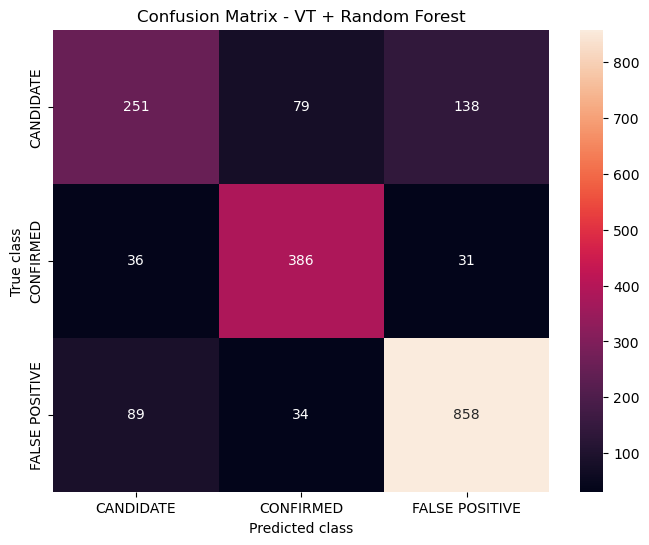

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("xtest_VT.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Random Forest")

plt.show();

Le Random Forest utilisant la sélection Variance Threshold fournit les meilleurs résultats parmi ces trois combinaisons.

Sur les 468 CANDIDATE, 258 sont correctement identifiés, contre 83 prédits CONFIRMED et 127 FALSE POSITIVE. Parmi les 453 CONFIRMED, 384 sont correctement classés, et parmi les 981 FALSE POSITIVE, 844 sont correctement reconnus.

La classe CANDIDATE reste la plus difficile à distinguer, mais ce modèle réduit les erreurs par rapport aux deux autres combinaisons. Il obtient également de meilleures performances pour les classes CONFIRMED et FALSE POSITIVE

### 4.2 Metrics


In [ ]:
class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")


print(f"Accuracy : {round(accuracy*100,3)} %" )
print(f"Precision macro : {round(precision*100,3)} %" )
print(f"Recall macro : {round(recall*100,3)} %" )
print(f"F1 macro : {round(f1*100,3)} %")
print("============================================================================================")
print(f"Classification report :", class_report)

Accuracy : 78.601 %
Precision macro : 75.885 %
Recall macro : 75.435 %
F1 macro : 75.343 %
Classification report :                 precision    recall  f1-score   support

     CANDIDATE       0.67      0.54      0.59       468
     CONFIRMED       0.77      0.85      0.81       453
FALSE POSITIVE       0.84      0.87      0.85       981

      accuracy                           0.79      1902
     macro avg       0.76      0.75      0.75      1902
  weighted avg       0.78      0.79      0.78      1902



### 4.3 Learning Curve – Overfitting / Underfitting Analysis

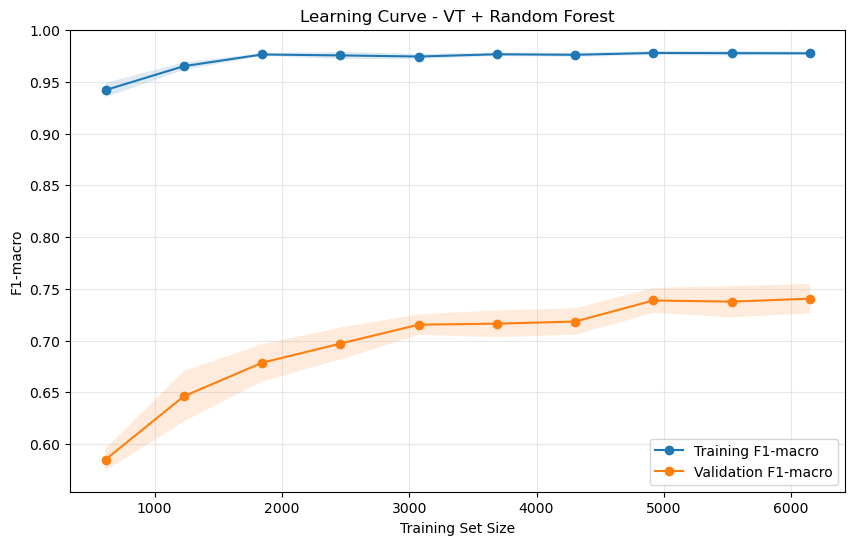

In [9]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_model,
    X=xtrain_VT,
    y=ytrain,
    groups=kepid_train,
    cv=Stratified_G_Kfold_cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training F1-macro"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation F1-macro"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Training Set Size")
plt.ylabel("F1-macro")
plt.title("Learning Curve - VT + Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show();

In [10]:
final_train_score = train_mean[-1]
final_validation_score = validation_mean[-1]
generalization_gap = final_train_score - final_validation_score

print("Final training F1-macro:", round(final_train_score, 4))
print("Final validation F1-macro:", round(final_validation_score, 4))
print("Generalization gap:", round(generalization_gap, 4))

Final training F1-macro: 0.9776
Final validation F1-macro: 0.7405
Generalization gap: 0.2371


#### Interpretation

La courbe d’apprentissage montre un écart persistant entre le score F1-macro obtenu sur les données d’entraînement et celui obtenu en validation.

Le score d’entraînement reste très élevé, autour de 0,98, tandis que le score de validation augmente progressivement jusqu’à environ 0,74. Cela indique que le Random Forest apprend très bien les données d’entraînement, mais qu’il généralise moins bien sur des données non vues.

Le modèle présente donc encore un surapprentissage (overfitting). Cependant, le score de validation continue à progresser lorsque la taille du jeu d’entraînement augmente, ce qui suggère qu’une quantité plus importante de données pourrait potentiellement améliorer sa capacité de généralisation.

L’optimisation des hyperparamètres a permis de réduire le surapprentissage par rapport au modèle de base, mais ne l’a pas complètement éliminé.

### 4.4 ROC and AUC 

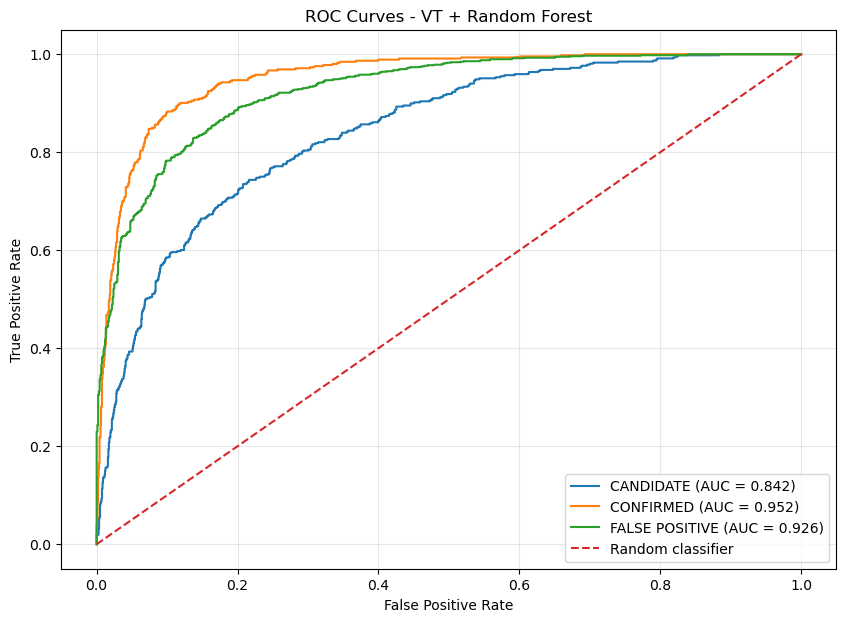

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
classes = best_model.classes_

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

y_proba = best_model.predict_proba(X_test_VT)

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_proba[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - VT + Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show();

In [12]:
macro_roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro",
    labels=classes
)

print("Macro ROC-AUC (OvR):", round(macro_roc_auc, 4))

Macro ROC-AUC (OvR): 0.9068


#### Interprétation

Les courbes ROC montrent que le modèle possède une bonne capacité globale de discrimination entre les trois classes.

La classe CONFIRMED obtient la meilleure AUC avec une valeur de 0,952, suivie par FALSE POSITIVE avec une AUC de 0,926. Ces résultats indiquent que le modèle distingue très efficacement ces deux classes des autres observations.

La classe CANDIDATE obtient une AUC plus faible de 0,842. Cette valeur reste satisfaisante, mais elle confirme que cette classe est la plus difficile à distinguer pour le modèle.

Cette difficulté peut s’expliquer par le caractère intermédiaire de la classe CANDIDATE : ces objets peuvent partager certaines caractéristiques avec les exoplanètes confirmées ainsi qu’avec les faux positifs.

La ROC-AUC est ici utilisée comme métrique complémentaire. Le F1-macro reste la métrique principale, car il permet d’accorder la même importance aux performances obtenues sur chacune des trois classes.

## 5. Model Limits

Cette combinaison obtient les meilleurs résultats des trois sur chacune des classes. Cela suggère que le maintien d’un ensemble relativement large de variables après Variance Threshold est bénéfique au Random Forest, qui peut exploiter des interactions entre plusieurs caractéristiques sans dépendre d’un seul arbre. Toutefois, la classe CANDIDATE reste la plus difficile à prédire, ce qui suggère qu’une partie de l’erreur pourrait provenir de l’ambiguïté intrinsèque de cette classe plutôt que d’un simple manque de capacité du modèle